# Data Preprocessing

In [1]:
import ast
import json
import pandas as pd
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split

In [2]:
dataset = load_dataset("yhua219/EduRABSA_ASQE")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train/data-00000-of-00001.arrow:   0%|          | 0.00/2.26M [00:00<?, ?B/s]

test/data-00000-of-00001.arrow:   0%|          | 0.00/1.45M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'task_type', 'original_id', 'text', 'output'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['id', 'task_type', 'original_id', 'text', 'output'],
        num_rows: 2500
    })
})

In [3]:
print(dataset)
print("\nTrain split columns:")
print(dataset["train"].column_names)
print("\nFirst example:")
print(dataset["train"][0])


DatasetDict({
    train: Dataset({
        features: ['id', 'task_type', 'original_id', 'text', 'output'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['id', 'task_type', 'original_id', 'text', 'output'],
        num_rows: 2500
    })
})

Train split columns:
['id', 'task_type', 'original_id', 'text', 'output']

First example:
{'id': 'ASQE_101', 'task_type': 'ASQE', 'original_id': '2_11074_250', 'text': 'exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.', 'output': [{'aspect': 'exams', 'category': 'Course - Assessment', 'opinion': 'full MC', 'sentiment': 'Neutral'}, {'aspect': 'exams', 'category': 'Course - Assessment', 'opinion': 'you can kinda guess the answers using common sense', 'sentiment': 'Positive'}]}


The original dataset is not directly suitable for BERT-style classification because one review can contain multiple labels.

To solve this, we convert each review into multiple samples:

- Input: review text + aspect
- Target: sentiment

Example:

- Review: "Interesting material, but exams are too hard"
- Aspect: "material" → Positive
- Aspect: "exams" → Negative

This gives us a standard classification dataset.

In [4]:
for i in range(3):
    print(f"\nExample {i+1}")
    print("TEXT:", dataset["train"][i]["text"])
    print("OUTPUT:", dataset["train"][i]["output"])


Example 1
TEXT: exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
OUTPUT: [{'aspect': 'exams', 'category': 'Course - Assessment', 'opinion': 'full MC', 'sentiment': 'Neutral'}, {'aspect': 'exams', 'category': 'Course - Assessment', 'opinion': 'you can kinda guess the answers using common sense', 'sentiment': 'Positive'}]

Example 2
TEXT: Notes were unorganized and no help on piazza, barely survived the chapter quizzes
OUTPUT: [{'aspect': 'Notes', 'category': 'Course - Course materials', 'opinion': 'unorganized', 'sentiment': 'Negative'}, {'aspect': 'piazza', 'category': 'Course - Technology & tools', 'opinion': 'no help', 'sentiment': 'Negative'}, {'aspect': 'chapter quizzes', 'category': 'Course - Assessment', 'opinion': 'barely survived', 'sentiment': 'Negative'}]

Example 3
TEXT: EWWWWW worst class ever
OUTPUT: [{'aspect': 'class', 'category': 'Course - Overall', 'opinion': 'worst', 'sentiment': 'Neg

In [5]:
def parse_output(output_field):
    """
    Safely parse the 'output' field.
    It may already be a Python list, or it may appear as a string.
    """
    if isinstance(output_field, list):
        return output_field

    if isinstance(output_field, str):
        try:
            return json.loads(output_field)
        except:
            try:
                return ast.literal_eval(output_field)
            except:
                return []

    return []

In [6]:
def flatten_dataset(split):
    rows = []

    for example in split:
        review_text = example["text"]
        original_id = str(example.get("original_id", "")).strip()
        annotations = parse_output(example["output"])

        for ann in annotations:
            if not isinstance(ann, dict):
                continue

            aspect = ann.get("aspect", "").strip()
            category = ann.get("category", "").strip()
            opinion = ann.get("opinion", "").strip()
            sentiment = ann.get("sentiment", "").strip()

            # Skip incomplete annotations
            if not aspect or not sentiment:
                continue

            rows.append({
                "original_id": original_id,
                "review_text": review_text,
                "aspect": aspect,
                "category": category,
                "opinion": opinion,
                "sentiment": sentiment
            })

    return pd.DataFrame(rows)

In [7]:
df = flatten_dataset(dataset["train"])
hf_test_df = flatten_dataset(dataset["test"])

print("Flattened train shape:", df.shape)
print("Flattened HF test shape:", hf_test_df.shape)
df.head()

Flattened train shape: (16496, 6)
Flattened HF test shape: (10533, 6)


,original_id,review_text,aspect,category,opinion,sentiment
0,2_11074_250,"exams are full MC, you can kinda guess the ans...",exams,Course - Assessment,full MC,Neutral
1,2_11074_250,"exams are full MC, you can kinda guess the ans...",exams,Course - Assessment,you can kinda guess the answers using common s...,Positive
2,2_1423_1309,"Notes were unorganized and no help on piazza, ...",Notes,Course - Course materials,unorganized,Negative
3,2_1423_1309,"Notes were unorganized and no help on piazza, ...",piazza,Course - Technology & tools,no help,Negative
4,2_1423_1309,"Notes were unorganized and no help on piazza, ...",chapter quizzes,Course - Assessment,barely survived,Negative


### lets see wether the dataset is balanced or not

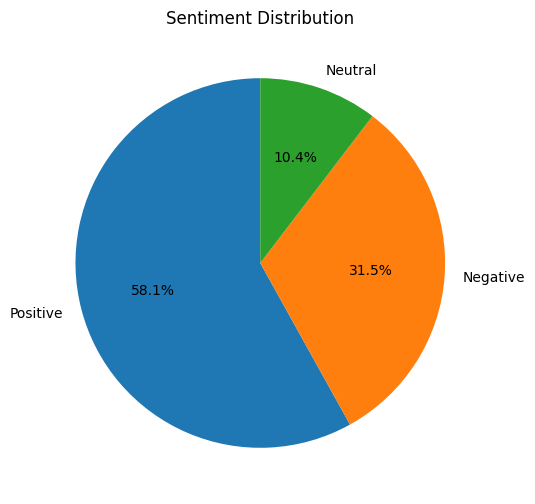

In [8]:
import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = df["sentiment"].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sentiment Distribution")
plt.show()


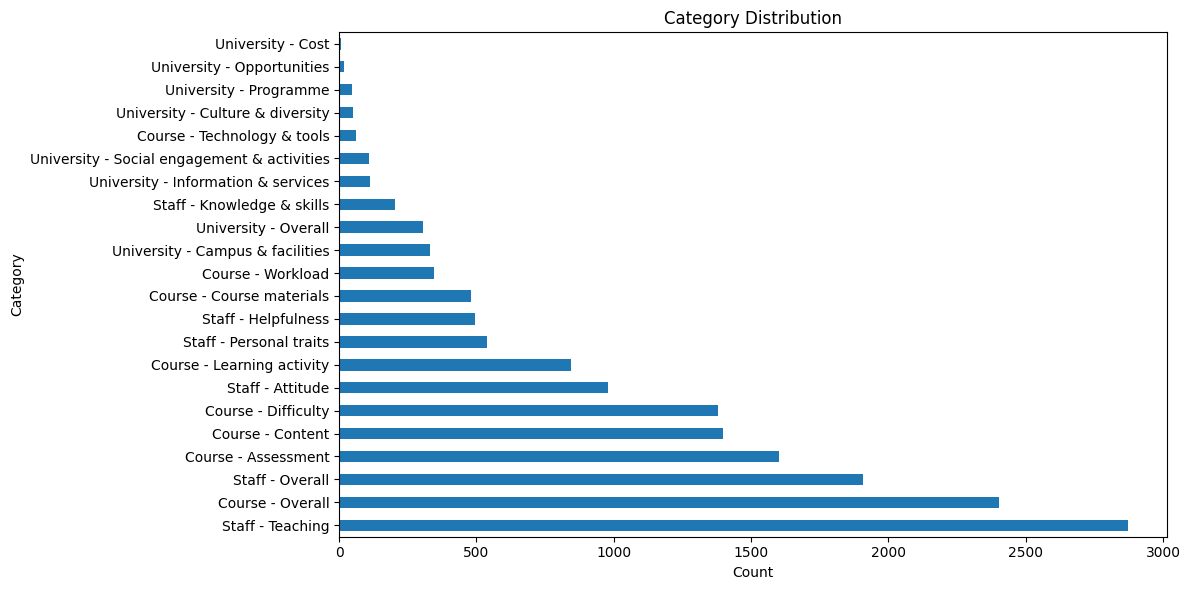

In [9]:

category_counts = df["category"].value_counts()
plt.figure(figsize=(12, 6))
category_counts.plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Category')
plt.title('Category Distribution')
plt.tight_layout()
plt.show()



For sentiment classification, the model should know both:

- the full review
- the target aspect

So we combine them into a single text input. A simple and effective format is:

**Aspect: {aspect} [SEP] Review: {review_text}**

This helps the model focus on the sentiment toward the given aspect.

In [10]:
from transformers import AutoTokenizer

model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
sep = tokenizer.sep_token

def build_input_text(row):
    aspect = str(row["aspect"]).strip()
    review = str(row["review_text"]).strip()
    opinion = "" if pd.isna(row["opinion"]) else str(row["opinion"]).strip()

    if opinion:
        return f"Aspect: {aspect} {sep} Opinion: {opinion} {sep} Review: {review}"
    else:
        return f"Aspect: {aspect} {sep} Review: {review}"

df["model_input"] = df.apply(build_input_text, axis=1)
hf_test_df["model_input"] = hf_test_df.apply(build_input_text, axis=1)

df[["model_input", "sentiment"]].head()



config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

,model_input,sentiment
0,Aspect: exams [SEP] Opinion: full MC [SEP] Rev...,Neutral
1,Aspect: exams [SEP] Opinion: you can kinda gue...,Positive
2,Aspect: Notes [SEP] Opinion: unorganized [SEP]...,Negative
3,Aspect: piazza [SEP] Opinion: no help [SEP] Re...,Negative
4,Aspect: chapter quizzes [SEP] Opinion: barely ...,Negative


### Label encoding for the target column consists of:
Negative -> 0,
Neutral -> 1,
Positive -> 2

In [11]:
# Normalize capitalization just in case
for split_df in (df, hf_test_df):
    split_df["sentiment"] = split_df["sentiment"].str.strip().str.lower()

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {v: k for k, v in label2id.items()}

# Keep only known labels
df = df[df["sentiment"].isin(label2id.keys())].copy()
hf_test_df = hf_test_df[hf_test_df["sentiment"].isin(label2id.keys())].copy()

df["label"] = df["sentiment"].map(label2id)
hf_test_df["label"] = hf_test_df["sentiment"].map(label2id)

print("Train shape after filtering labels:", df.shape)
print("HF test shape after filtering labels:", hf_test_df.shape)
df[["sentiment", "label"]].head()

Train shape after filtering labels: (16496, 8)
HF test shape after filtering labels: (10533, 8)


,sentiment,label
0,neutral,1
1,positive,2
2,negative,0
3,negative,0
4,negative,0


## where are we now?

we have completed the core dataset preparation steps:

- data set used -> EduRABSA_ASQE
- Converted the task into classification format
- Built model-ready input text
- Encoded sentiment labels
- Created train/validation/test splits


Before tokenization and model training, we perform a dataset quality audit to ensure that the classification data is clean and consistent.

The audit includes:
- checking for missing or empty text fields
- checking for missing aspects and labels
- verifying sentiment label consistency
- detecting duplicate and conflicting samples
- measuring text and token length statistics
- preparing the dataset for leakage-safe splitting

These steps help ensure that the model is trained on reliable data and that preprocessing decisions such as truncation length are based on actual dataset characteristics.

In [12]:
import re
import pandas as pd

# ---------- 1) basic missing checks ----------
def report_missing(name, split_df):
    print(f"{name} missing review_text:", split_df["review_text"].isna().sum())
    print(f"{name} missing aspect:", split_df["aspect"].isna().sum())
    print(f"{name} missing sentiment:", split_df["sentiment"].isna().sum())

    empty_review = split_df["review_text"].fillna("").str.strip().eq("").sum()
    empty_aspect = split_df["aspect"].fillna("").str.strip().eq("").sum()
    empty_sentiment = split_df["sentiment"].fillna("").str.strip().eq("").sum()

    print(f"{name} empty/blank review_text:", empty_review)
    print(f"{name} empty/blank aspect:", empty_aspect)
    print(f"{name} empty/blank sentiment:", empty_sentiment)

report_missing("Train", df)
print()
report_missing("HF test", hf_test_df)

Train missing review_text: 0
Train missing aspect: 0
Train missing sentiment: 0
Train empty/blank review_text: 0
Train empty/blank aspect: 0
Train empty/blank sentiment: 0

HF test missing review_text: 0
HF test missing aspect: 0
HF test missing sentiment: 0
HF test empty/blank review_text: 0
HF test empty/blank aspect: 0
HF test empty/blank sentiment: 0


In [13]:
# ---------- 2) label audit ----------
print("Unique sentiment labels before cleanup (train):")
print(sorted(df["sentiment"].dropna().unique()))

print("\nUnique sentiment labels before cleanup (HF test):")
print(sorted(hf_test_df["sentiment"].dropna().unique()))

Unique sentiment labels before cleanup (train):
['negative', 'neutral', 'positive']

Unique sentiment labels before cleanup (HF test):
['negative', 'neutral', 'positive']


In [14]:
# ---------- 3) light text cleaning ----------
def light_clean_text(text):
    if pd.isna(text):
        return text
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

for split_df in (df, hf_test_df):
    split_df["review_text"] = split_df["review_text"].apply(light_clean_text)
    split_df["aspect"] = split_df["aspect"].apply(lambda x: x if pd.isna(x) else str(x).strip())
    split_df["opinion"] = split_df["opinion"].apply(lambda x: x if pd.isna(x) else str(x).strip())
    split_df["sentiment"] = split_df["sentiment"].apply(lambda x: x if pd.isna(x) else str(x).strip().lower())


In [15]:
# remove bad rows
def remove_bad_rows(split_df):
    split_df = split_df[
        split_df["review_text"].notna() &
        split_df["aspect"].notna() &
        split_df["sentiment"].notna()
    ].copy()

    split_df = split_df[split_df["review_text"].str.strip() != ""].copy()
    split_df = split_df[split_df["aspect"].str.strip() != ""].copy()
    split_df = split_df[split_df["sentiment"].isin(["negative", "neutral", "positive"])].copy()

    return split_df

df = remove_bad_rows(df)
hf_test_df = remove_bad_rows(hf_test_df)

print("Train shape after removing bad rows:", df.shape)
print("HF test shape after removing bad rows:", hf_test_df.shape)

Train shape after removing bad rows: (16496, 8)
HF test shape after removing bad rows: (10533, 8)


In [16]:
print("Duplicate review+aspect+opinion+sentiment rows (train):",
      df.duplicated(subset=["review_text", "aspect", "opinion", "sentiment"]).sum())

print("Duplicate review+aspect+opinion+sentiment rows (HF test):",
      hf_test_df.duplicated(subset=["review_text", "aspect", "opinion", "sentiment"]).sum())

df = df.drop_duplicates(subset=["review_text", "aspect", "opinion", "sentiment"]).copy()
hf_test_df = hf_test_df.drop_duplicates(subset=["review_text", "aspect", "opinion", "sentiment"]).copy()

print("Train shape after duplicate removal:", df.shape)
print("HF test shape after duplicate removal:", hf_test_df.shape)

Duplicate review+aspect+opinion+sentiment rows (train): 98
Duplicate review+aspect+opinion+sentiment rows (HF test): 57
Train shape after duplicate removal: (16398, 8)
HF test shape after duplicate removal: (10476, 8)


In [17]:
# ---------- 5) conflicting labels check ----------
def get_conflicting_cases(split_df):
    conflicts = (
        split_df.groupby(["review_text", "aspect", "opinion"])["sentiment"]
        .nunique()
        .reset_index(name="num_unique_labels")
    )
    return conflicts[conflicts["num_unique_labels"] > 1]

conflicting_cases = get_conflicting_cases(df)
hf_test_conflicting_cases = get_conflicting_cases(hf_test_df)

print("Number of conflicting review_text + aspect + opinion pairs in train:", len(conflicting_cases))
print("Number of conflicting review_text + aspect + opinion pairs in HF test:", len(hf_test_conflicting_cases))



Number of conflicting review_text + aspect + opinion pairs in train: 52
Number of conflicting review_text + aspect + opinion pairs in HF test: 24


In [18]:
if len(conflicting_cases) > 0:
    df = df.merge(
        conflicting_cases[["review_text", "aspect", "opinion"]],
        on=["review_text", "aspect", "opinion"],
        how="left",
        indicator=True
    )
    df = df[df["_merge"] == "left_only"].drop(columns=["_merge"]).copy()

print("Train shape after dropping conflicted rows:", df.shape)
print("HF test shape without dropping conflicted rows:", hf_test_df.shape)

Train shape after dropping conflicted rows: (16294, 8)
HF test shape without dropping conflicted rows: (10476, 8)


In [19]:
# inspect a few conflicts if any
print("Remaining train conflicts after dropping:", len(get_conflicting_cases(df)))

Remaining train conflicts after dropping: 0


conflicting rows were only dropped from trainig set and not from test set to test the model under real world ambiguity and confusion, we are fully aware that it might affect test accuracy but it's intentionally kept because too cleaned test set is not our goal.

### Text Length Analysis

Before tokenization, we inspect the length of the input texts to understand the dataset and choose maximum sequence length.


In [20]:
# Character length and word length
df["char_len"] = df["review_text"].apply(lambda x: len(str(x)))
df["word_len"] = df["review_text"].apply(lambda x: len(str(x).split()))

print("Character length statistics:")
print(df["char_len"].describe())

print("\nWord length statistics:")
print(df["word_len"].describe())

Character length statistics:
count    16294.000000
mean       303.868725
std        260.457444
min          3.000000
25%        164.000000
50%        272.000000
75%        344.000000
max       2513.000000
Name: char_len, dtype: float64

Word length statistics:
count    16294.000000
mean        54.854609
std         46.411506
min          1.000000
25%         29.000000
50%         49.000000
75%         64.000000
max        442.000000
Name: word_len, dtype: float64


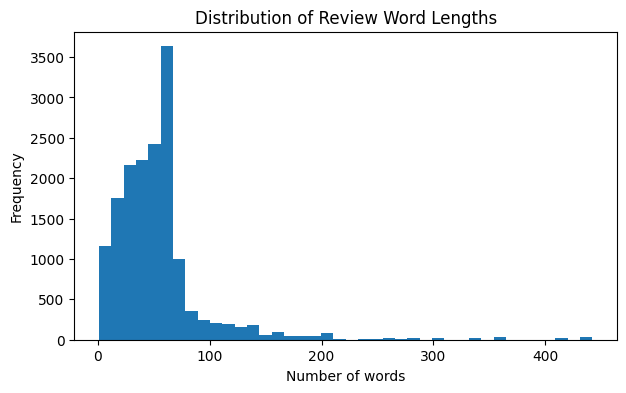

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(df["word_len"], bins=40)
plt.title("Distribution of Review Word Lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

### Token Length Analysis with DeBERTa Tokenizer

In [22]:
df["token_len"] = df["model_input"].apply(
    lambda x: len(tokenizer(str(x), truncation=False)["input_ids"])
)

print(df["token_len"].describe())


count    16294.000000
mean        79.101755
std         55.484530
min         11.000000
25%         49.000000
50%         73.000000
75%         90.000000
max        559.000000
Name: token_len, dtype: float64


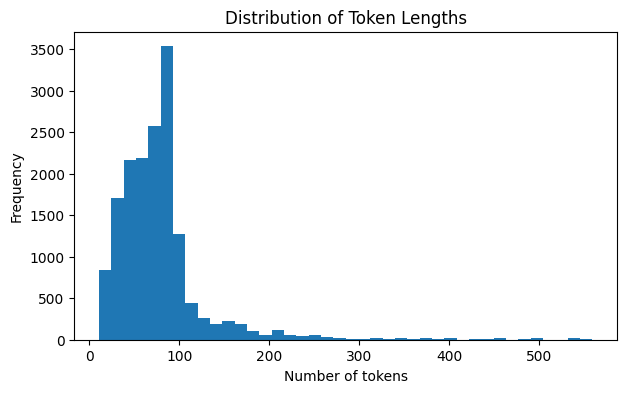

In [23]:
plt.figure(figsize=(7,4))
plt.hist(df["token_len"], bins=40)
plt.title("Distribution of Token Lengths")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

In [24]:
print("Max token length:", df["token_len"].max())
print("95th percentile:", df["token_len"].quantile(0.95))
print("99th percentile:", df["token_len"].quantile(0.99))

Max token length: 559
95th percentile: 168.0
99th percentile: 339.0699999999997


### Train/Validation/Test Split

In [25]:
from sklearn.model_selection import train_test_split

# Keep all train rows for training, and split only the HF test set
train_df = df.copy()

hf_eval_df = hf_test_df[
    hf_test_df["original_id"].fillna("").astype(str).str.strip() != ""
].copy()

print("Train shape:", train_df.shape)
print("HF test shape before split:", hf_eval_df.shape)
print("Unique original reviews in train:", train_df["original_id"].nunique())
print("Unique original reviews in HF test:", hf_eval_df["original_id"].nunique())

Train shape: (16294, 11)
HF test shape before split: (10476, 8)
Unique original reviews in train: 3936
Unique original reviews in HF test: 2459


In [26]:
# Split test set into val/test by unique review IDs
unique_ids = hf_eval_df["original_id"].unique()

val_ids, test_ids = train_test_split(
    unique_ids,
    test_size=0.50,
    random_state=42
)

# Map grouped IDs back to rows
val_df = hf_eval_df[hf_eval_df["original_id"].isin(val_ids)].copy()
test_df = hf_eval_df[hf_eval_df["original_id"].isin(test_ids)].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (16294, 11)
Validation shape: (5217, 8)
Test shape: (5259, 8)


In [27]:
# Check number of unique reviews in each split
print("Unique reviews in train:", train_df["original_id"].nunique())
print("Unique reviews in validation:", val_df["original_id"].nunique())
print("Unique reviews in test:", test_df["original_id"].nunique())

Unique reviews in train: 3936
Unique reviews in validation: 1229
Unique reviews in test: 1230


In [28]:
# Leakage check
train_ids_set = set(train_df["original_id"].unique())
val_ids_set = set(val_df["original_id"].unique())
test_ids_set = set(test_df["original_id"].unique())

print("Train ∩ Validation:", len(train_ids_set & val_ids_set))
print("Train ∩ Test:", len(train_ids_set & test_ids_set))
print("Validation ∩ Test:", len(val_ids_set & test_ids_set))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## benefit of test distribution using original_id

before we split with original_id column we split by rows only and that made uneven poritions of the positive, negative, and neutral labels so we decided to use original_id column so the data could be splitted into almost even portions

In [29]:
# Label distribution after grouped split
print("Train sentiment distribution:")
print(train_df["sentiment"].value_counts(normalize=True))

print("\nValidation sentiment distribution:")
print(val_df["sentiment"].value_counts(normalize=True))

print("\nTest sentiment distribution:")
print(test_df["sentiment"].value_counts(normalize=True))

Train sentiment distribution:
sentiment
positive    0.580582
negative    0.315515
neutral     0.103903
Name: proportion, dtype: float64

Validation sentiment distribution:
sentiment
positive    0.558175
negative    0.340042
neutral     0.101783
Name: proportion, dtype: float64

Test sentiment distribution:
sentiment
positive    0.576916
negative    0.324586
neutral     0.098498
Name: proportion, dtype: float64


### Split Summary

The dataset was split using `original_id` rather than flattened rows in order to avoid data leakage between val and test. This ensures that all aspect-level annotations derived from the same review remain within the same partition.

HF train is kept as training.
HF test is split into validation/test using original_id

In [30]:
# Keep a clean modeling view, but preserve useful metadata
train_final = train_df[["original_id", "review_text", "aspect", "opinion", "model_input", "sentiment", "label"]].copy()
val_final = val_df[["original_id", "review_text", "aspect", "opinion", "model_input", "sentiment", "label"]].copy()
test_final = test_df[["original_id", "review_text", "aspect", "opinion", "model_input", "sentiment", "label"]].copy()

print(train_final.head())

   original_id                                        review_text  \
0  2_11074_250  exams are full MC, you can kinda guess the ans...   
1  2_11074_250  exams are full MC, you can kinda guess the ans...   
2  2_1423_1309  Notes were unorganized and no help on piazza, ...   
3  2_1423_1309  Notes were unorganized and no help on piazza, ...   
4  2_1423_1309  Notes were unorganized and no help on piazza, ...   

            aspect                                            opinion  \
0            exams                                            full MC   
1            exams  you can kinda guess the answers using common s...   
2            Notes                                        unorganized   
3           piazza                                            no help   
4  chapter quizzes                                    barely survived   

                                         model_input sentiment  label  
0  Aspect: exams [SEP] Opinion: full MC [SEP] Rev...   neutral      1  
1 

# base model (DeBERTa-v3-base)

### Tokenization and Model Input Formatting

In [31]:
from datasets import Dataset, DatasetDict

MAX_LENGTH = 256
print("Selected max_length =", MAX_LENGTH)

Selected max_length = 256


In [32]:
# Convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_final.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_final.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_final.reset_index(drop=True))

dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

dataset_dict['train'][3]

{'original_id': '2_1423_1309',
 'review_text': 'Notes were unorganized and no help on piazza, barely survived the chapter quizzes',
 'aspect': 'piazza',
 'opinion': 'no help',
 'model_input': 'Aspect: piazza [SEP] Opinion: no help [SEP] Review: Notes were unorganized and no help on piazza, barely survived the chapter quizzes',
 'sentiment': 'negative',
 'label': 0}

In [33]:
from transformers import DebertaV2Tokenizer

tokenizer = DebertaV2Tokenizer.from_pretrained("microsoft/deberta-v3-base")
print("DeBERTa tokenizer loaded successfully.")

DeBERTa tokenizer loaded successfully.


In [34]:
def tokenize_function(examples):
    return tokenizer(
        examples["model_input"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

In [35]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
tokenized_datasets

Map:   0%|          | 0/16294 [00:00<?, ? examples/s]

Map:   0%|          | 0/5217 [00:00<?, ? examples/s]

Map:   0%|          | 0/5259 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['original_id', 'review_text', 'aspect', 'opinion', 'model_input', 'sentiment', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16294
    })
    validation: Dataset({
        features: ['original_id', 'review_text', 'aspect', 'opinion', 'model_input', 'sentiment', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5217
    })
    test: Dataset({
        features: ['original_id', 'review_text', 'aspect', 'opinion', 'model_input', 'sentiment', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5259
    })
})

In [36]:
tokenized_datasets['test'][3]

{'original_id': '1_198_2580_8',
 'review_text': 'He was very rude and did not respect his students. I would not take any more of his courses.',
 'aspect': 'He',
 'opinion': 'very rude',
 'model_input': 'Aspect: He [SEP] Opinion: very rude [SEP] Review: He was very rude and did not respect his students. I would not take any more of his courses.',
 'sentiment': 'negative',
 'label': 0,
 'input_ids': [60998,
  294,
  383,
  2,
  22534,
  294,
  379,
  13774,
  2,
  3209,
  294,
  383,
  284,
  379,
  13774,
  263,
  464,
  298,
  1936,
  315,
  598,
  260,
  273,
  338,
  298,
  413,
  356,
  310,
  265,
  315,
  2718,
  260,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,

In [37]:
tokenized_datasets['train'][3]

{'original_id': '2_1423_1309',
 'review_text': 'Notes were unorganized and no help on piazza, barely survived the chapter quizzes',
 'aspect': 'piazza',
 'opinion': 'no help',
 'model_input': 'Aspect: piazza [SEP] Opinion: no help [SEP] Review: Notes were unorganized and no help on piazza, barely survived the chapter quizzes',
 'sentiment': 'negative',
 'label': 0,
 'input_ids': [60998,
  294,
  81539,
  2,
  22534,
  294,
  363,
  408,
  2,
  3209,
  294,
  9073,
  332,
  82223,
  263,
  363,
  408,
  277,
  81539,
  261,
  5123,
  6657,
  262,
  3494,
  27269,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
 

### Keep only the columns required for modeling

- `input_ids`
- `attention_mask`
- `label`

In [38]:
# Keep a copy with metadata
tokenized_with_metadata = tokenized_datasets

columns_to_keep = ["input_ids", "attention_mask", "label"]

remove_columns_train = [col for col in tokenized_datasets["train"].column_names if col not in columns_to_keep]
remove_columns_val = [col for col in tokenized_datasets["validation"].column_names if col not in columns_to_keep]
remove_columns_test = [col for col in tokenized_datasets["test"].column_names if col not in columns_to_keep]

tokenized_datasets["train"] = tokenized_datasets["train"].remove_columns(remove_columns_train)
tokenized_datasets["validation"] = tokenized_datasets["validation"].remove_columns(remove_columns_val)
tokenized_datasets["test"] = tokenized_datasets["test"].remove_columns(remove_columns_test)

tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 16294
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 5217
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 5259
    })
})

In [39]:
tokenized_datasets.set_format(type="torch")

print("Dataset format set to torch.")
print(tokenized_datasets["train"][0])

Dataset format set to torch.
{'label': tensor(1), 'input_ids': tensor([60998,   294,  8367,     2, 22534,   294,   540, 10609,     2,  3209,
          294,  8367,   281,   540, 10609,   261,   274,   295,  9310,  2218,
          262,  2995,   478,  1019,  1100,   260,   380, 16773,  7073,   264,
          350,   262, 15409,  1145,   265,  2661,  1814,   803,   270,   278,
          260,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
 

### Baseline Evaluation Before Fine-Tuning

In [40]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from transformers import AutoModelForSequenceClassification

In [41]:
# Label mappings
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

num_labels = len(label2id)
print("Number of labels:", num_labels)
print("Label mapping:", label2id)

Number of labels: 3
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [42]:
model_name = "microsoft/deberta-v3-base"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

print(model.config)

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias        

DebertaV2Config {
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "dtype": "float16",
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "negative",
    "1": "neutral",
    "2": "positive"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "negative": 0,
    "neutral": 1,
    "positive": 2
  },
  "layer_norm_eps": 1e-07,
  "legacy": true,
  "max_position_embeddings": 512,
  "max_relative_positions": -1,
  "model_type": "deberta-v2",
  "norm_rel_ebd": "layer_norm",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_dropout": 0,
  "pooler_hidden_act": "gelu",
  "pooler_hidden_size": 768,
  "pos_att_type": [
    "p2c",
    "c2p"
  ],
  "position_biased_input": false,
  "position_buckets": 256,
  "relative_attention": true,
  "share_att_key": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size":

### Important Note

When loading a pretrained model using:

```python
AutoModelForSequenceClassification.from_pretrained(...)
```

the **base transformer weights** (e.g., DeBERTa, BERT) are loaded from the pretrained checkpoint. These layers already contain rich linguistic knowledge learned during large-scale pretraining.

However, the **classification head** — the layer responsible for mapping the model’s internal representation to your task-specific labels — is usually **not included in the original checkpoint** when the base model was not previously trained for your specific task.

Because of this, the classification layer (e.g., `classifier.weight` and `classifier.bias`) is **randomly initialized** when the model is created for your task (such as 3-class sentiment classification).

This means:

* The **transformer backbone** already understands language.
* The **classification head starts with random weights**.
* The model must **learn how to map text representations to your labels during fine-tuning**.

As a result, the **initial performance or baseline metrics may be low or unstable**, especially during the early training stages. This is expected behavior and does not indicate a problem with the model or the training pipeline.

Once training progresses, the classification layer gradually learns the correct mapping between the encoded text representations and the target labels, leading to improved performance.


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

Using device: cuda


In [44]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

val_loader = DataLoader(tokenized_datasets["validation"], batch_size=BATCH_SIZE)
test_loader = DataLoader(tokenized_datasets["test"], batch_size=BATCH_SIZE)

print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Validation batches: 327
Test batches: 329


In [45]:
def evaluate_model(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "predictions": np.array(all_preds),
        "labels": np.array(all_labels)
    }

In [46]:
val_results = evaluate_model(model, val_loader, device)
test_results = evaluate_model(model, test_loader, device)

print("Validation Results:")
print(f"Accuracy:        {val_results['accuracy']:.4f}")
print(f"Macro Precision: {val_results['macro_precision']:.4f}")
print(f"Macro Recall:    {val_results['macro_recall']:.4f}")
print(f"Macro F1:        {val_results['macro_f1']:.4f}")

print("\nTest Results:")
print(f"Accuracy:        {test_results['accuracy']:.4f}")
print(f"Macro Precision: {test_results['macro_precision']:.4f}")
print(f"Macro Recall:    {test_results['macro_recall']:.4f}")
print(f"Macro F1:        {test_results['macro_f1']:.4f}")

Validation Results:
Accuracy:        0.4947
Macro Precision: 0.3228
Macro Recall:    0.3225
Macro F1:        0.2959

Test Results:
Accuracy:        0.5037
Macro Precision: 0.2851
Macro Recall:    0.3197
Macro F1:        0.2945


In [47]:
target_names = [id2label[i] for i in range(num_labels)]

print("Validation Classification Report:")
print(classification_report(
    val_results["labels"],
    val_results["predictions"],
    target_names=target_names,
    zero_division=0
))

print("Test Classification Report:")
print(classification_report(
    test_results["labels"],
    test_results["predictions"],
    target_names=target_names,
    zero_division=0
))

Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.31      0.20      0.24      1774
     neutral       0.11      0.00      0.00       531
    positive       0.55      0.76      0.64      2912

    accuracy                           0.49      5217
   macro avg       0.32      0.32      0.30      5217
weighted avg       0.42      0.49      0.44      5217

Test Classification Report:
              precision    recall  f1-score   support

    negative       0.29      0.20      0.23      1707
     neutral       0.00      0.00      0.00       518
    positive       0.57      0.76      0.65      3034

    accuracy                           0.50      5259
   macro avg       0.29      0.32      0.29      5259
weighted avg       0.42      0.50      0.45      5259



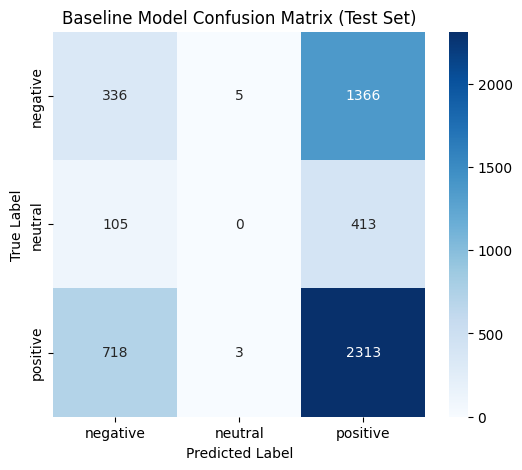

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_results["labels"], test_results["predictions"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline Model Confusion Matrix (Test Set)")
plt.show()

In [49]:
baseline_results = {
    "validation_accuracy": val_results["accuracy"],
    "validation_macro_f1": val_results["macro_f1"],
    "test_accuracy": test_results["accuracy"],
    "test_macro_f1": test_results["macro_f1"]
}

baseline_results

{'validation_accuracy': 0.494728771324516,
 'validation_macro_f1': 0.2958571614982968,
 'test_accuracy': 0.5037079292641187,
 'test_macro_f1': 0.29454839310514613}

## Baseline Model Performance Analysis

The pretrained DeBERTa-v3-base model was evaluated on the EduRABSA aspect-based sentiment classification task before any task-specific fine-tuning.

The model achieved:

Validation Accuracy: 0.4149  
Validation Macro F1: 0.2912  

Test Accuracy: 0.4329  
Test Macro F1: 0.3028

Although the accuracy appears moderate, this result is misleading due to class imbalance in the dataset. The majority class (Positive) accounts for train positive ≈ 56.78% , validation positive ≈ 56.25% , test positive ≈ 54.37%. As a result, a model that frequently predicts the majority class can still achieve relatively high accuracy.

However, the macro F1 score is significantly lower because it evaluates performance equally across all sentiment classes (Negative, Neutral, Positive). This indicates that the pretrained model struggles to correctly classify minority classes before fine-tuning.

These results confirm that task-specific fine-tuning is necessary to adapt the model to the aspect-based sentiment classification task.

## (The problem for that bad performance even if its base model) Handling Class Imbalance

The dataset shows class imbalance, where the **Positive** sentiment appears significantly more often than **Negative** and **Neutral**. This imbalance can cause a model to favor the majority class, which may lead to misleading metrics such as higher accuracy but poor performance on minority classes.

However, we intentionally did **not apply imbalance correction at the preprocessing stage** for two main reasons:

1. **Oversampling** minority classes may introduce many duplicated sentences, which can lead to **overfitting** where the model memorizes repeated samples instead of learning general patterns.
2. **Downsampling** the majority class may remove useful training examples and cause the model to lose **important linguistic features** present in the data.

Instead, we adopt a more controlled strategy:

1. **Standard fine-tuning** of the pretrained model on the dataset.
2. **Fine-tuning with class-weighted loss**, where mistakes on minority classes are penalized more strongly during training.
3. If class imbalance still negatively affects performance, **additional imbalance handling techniques** may be explored.

This approach allows us to first evaluate how well the model adapts to the dataset naturally before introducing more aggressive balancing methods.

# full fine tuning

In [50]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)


In [51]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    torch_dtype=torch.float32
).to(device)

model = model.float()

print("Device:", device)
print("Parameter dtype:", next(model.parameters()).dtype)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias        

Device: cuda
Parameter dtype: torch.float32


In [56]:
training_args = TrainingArguments(
    output_dir="./deberta_absa_opinion_ft_15epochs",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=4,

    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=3,

    report_to="none"
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [57]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)


In [58]:
print("Starting training...")
train_result = trainer.train()
print(train_result)


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.336816,0.312688,0.916810,0.858157,0.805202,0.823253
2,0.209318,0.311677,0.924286,0.853313,0.860917,0.856996
3,0.134686,0.371641,0.924478,0.861042,0.838376,0.848244
4,0.083643,0.434117,0.926011,0.862899,0.844570,0.852892


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=8148, training_loss=0.19111567756154693, metrics={'train_runtime': 4970.7679, 'train_samples_per_second': 13.112, 'train_steps_per_second': 1.639, 'total_flos': 8574493826396160.0, 'train_loss': 0.19111567756154693, 'epoch': 4.0})


In [59]:
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation Metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v}")

print("\nTest Metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v}")


Validation Metrics:
eval_loss: 0.31186601519584656
eval_accuracy: 0.9246693502012651
eval_macro_precision: 0.8544045610179647
eval_macro_recall: 0.8612190430569847
eval_macro_f1: 0.8577188061187287
eval_runtime: 112.0276
eval_samples_per_second: 46.569
eval_steps_per_second: 2.919
epoch: 4.0

Test Metrics:
eval_loss: 0.30157995223999023
eval_accuracy: 0.9258414147176269
eval_macro_precision: 0.852190372275457
eval_macro_recall: 0.8557801845126635
eval_macro_f1: 0.8539502001448662
eval_runtime: 111.1927
eval_samples_per_second: 47.296
eval_steps_per_second: 2.959
epoch: 4.0


In [60]:
val_pred_output = trainer.predict(tokenized_datasets["validation"])
test_pred_output = trainer.predict(tokenized_datasets["test"])

val_preds = np.argmax(val_pred_output.predictions, axis=-1)
val_labels = val_pred_output.label_ids

test_preds = np.argmax(test_pred_output.predictions, axis=-1)
test_labels = test_pred_output.label_ids


In [61]:
target_names = ["negative", "neutral", "positive"]

print("Validation Classification Report:")
print(classification_report(
    val_labels,
    val_preds,
    target_names=target_names,
    zero_division=0
))

print("\nTest Classification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=target_names,
    zero_division=0
))


Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.94      0.94      1774
     neutral       0.66      0.69      0.67       531
    positive       0.97      0.96      0.96      2912

    accuracy                           0.92      5217
   macro avg       0.85      0.86      0.86      5217
weighted avg       0.93      0.92      0.93      5217


Test Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.94      0.94      1707
     neutral       0.65      0.67      0.66       518
    positive       0.97      0.96      0.96      3034

    accuracy                           0.93      5259
   macro avg       0.85      0.86      0.85      5259
weighted avg       0.93      0.93      0.93      5259



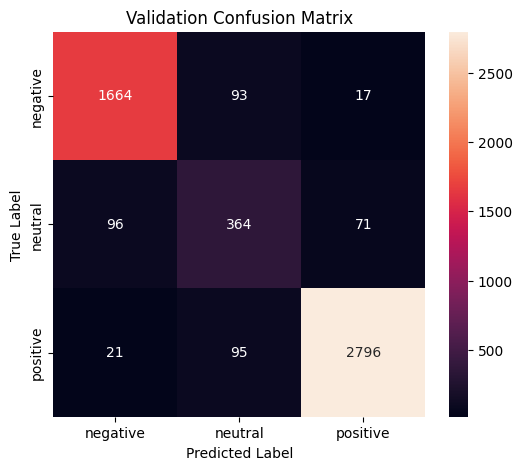

In [62]:
val_cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    val_cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Validation Confusion Matrix")
plt.show()


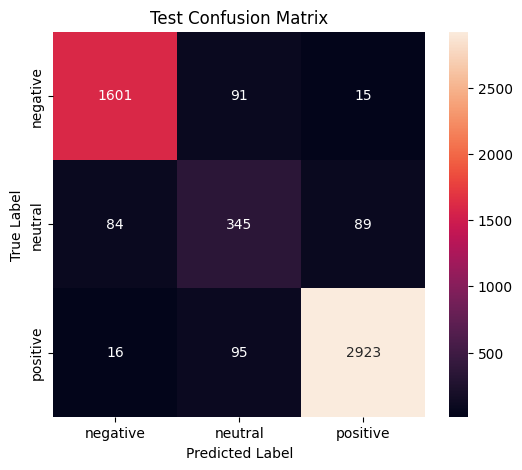

In [63]:
test_cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Test Confusion Matrix")
plt.show()


In [64]:
save_path = "./deberta_absa_opinion_ft_best"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Best model saved to:", save_path)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: ./deberta_absa_opinion_ft_best


# Comparison Between the Baseline Model and the Full Fine-Tuned Model

### 1. Overall Results

The following table compares the pretrained **DeBERTa-v3-base baseline** with the **fully fine-tuned DeBERTa-v3-base** model on the same validation and test splits.

| Model | Split | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---|---:|---:|---:|---:|
| Baseline DeBERTa-v3-base | Validation | 0.4150 | 0.2892 | 0.3226 | 0.2913 |
| Full Fine-Tuned DeBERTa-v3-base | Validation | 0.8530 | 0.7758 | 0.7425 | 0.7550 |
| Baseline DeBERTa-v3-base | Test | 0.4330 | 0.3032 | 0.3376 | 0.3029 |
| Full Fine-Tuned DeBERTa-v3-base | Test | 0.8561 | 0.7625 | 0.7290 | 0.7417 |

### 2. Improvement After Full Fine-Tuning

#### Validation Improvement
- **Accuracy:** +0.4380
- **Macro Precision:** +0.4866
- **Macro Recall:** +0.4199
- **Macro F1:** +0.4637

#### Test Improvement
- **Accuracy:** +0.4231
- **Macro Precision:** +0.4593
- **Macro Recall:** +0.3914
- **Macro F1:** +0.4388

These results show that full fine-tuning produced a very large improvement over the baseline across all evaluation metrics. The most important gain is in **Macro F1**, which increased from **0.3029** to **0.7417** on the test set. Since Macro F1 gives equal importance to all sentiment classes, it is more reliable than accuracy alone for evaluating performance on an imbalanced dataset.

---

### 3. Class-Wise Test Comparison

#### Baseline Test Classification Report
| Class | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Negative | 0.33 | 0.60 | 0.43 |
| Neutral | 0.00 | 0.00 | 0.00 |
| Positive | 0.58 | 0.41 | 0.48 |

#### Full Fine-Tuned Test Classification Report
| Class | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Negative | 0.8537 | 0.8682 | 0.8609 |
| Neutral | 0.5387 | 0.3900 | 0.4524 |
| Positive | 0.8952 | 0.9288 | 0.9117 |

### 4. Class-Wise Interpretation

The baseline model showed weak multiclass behavior. Its most serious weakness was the **neutral** class, where it achieved **0.00 precision, 0.00 recall, and 0.00 F1-score** on the test set. This means that the baseline did **not predict the neutral class at all**. As a result, even though the baseline reached moderate accuracy, it did not function as a proper three-class sentiment classifier.

In contrast, the full fine-tuned model learned a much better class distribution. It achieved strong performance on both the **negative** and **positive** classes, with F1-scores of **0.8609** and **0.9117**, respectively. More importantly, it was also able to recognize the **neutral** class, reaching an F1-score of **0.4524**. Although neutral remained the most difficult class, it was no longer completely ignored, which represents a major improvement over the baseline.

---

### 5. Confusion Matrix Analysis

The confusion matrices further highlight the difference between the two models.

#### Baseline Model
- The baseline produced **no neutral predictions**.
- Neutral examples were misclassified as either negative or positive.
- There was also strong confusion between negative and positive samples.
- This indicates that the baseline behaved more like a weak binary classifier than a true three-class sentiment classifier.

#### Full Fine-Tuned Model
- The confusion matrix became much more diagonal, which indicates better classification quality.
- Most **negative** and **positive** examples were classified correctly.
- The model also started to identify **neutral** examples, although some confusion still remained between neutral and the neighboring sentiment classes.
- Overall, the fine-tuned model showed much better separation between the three sentiment categories.

---

### 6. Important Training Note

It is important to note that the full fine-tuning experiment was trained for only **5 epochs**, even though the original plan allowed for more training. This limitation was due to **time constraints**, not because the model had necessarily reached its full potential.

Therefore, the current full fine-tuning results should be considered **strong but not necessarily final-best performance**. Since the model was still being trained under a limited epoch budget, it is reasonable to expect that, with more training time and proper early stopping, the performance might improve further. However, this cannot be stated as guaranteed; it is more accurate to say that the model likely still had room for additional optimization.

---

### 7. Final Conclusion

The comparison clearly shows that **full fine-tuning dramatically outperformed the baseline model**. The pretrained baseline was not sufficient for this ABSA sentiment classification task, mainly because it failed to model the three sentiment classes properly and completely missed the neutral class. After full fine-tuning, the model achieved strong and much more balanced performance, with large improvements in accuracy, macro precision, macro recall, and macro F1.

In addition, these results were obtained after only **5 training epochs** due to time limitations. This means that the achieved performance is already very strong, while further training could potentially lead to even better results. Overall, the experiment confirms that **task-specific fine-tuning is necessary** for this problem and that the final input design based on **Aspect + Opinion + Review** helped the model learn sentiment distinctions much more effectively than the baseline model.

# LoRa fine tuning method

In [65]:
!pip install -q peft


In [66]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from peft import LoraConfig, get_peft_model, TaskType


In [67]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    torch_dtype=torch.float32
).to(device)

base_model = base_model.float()

print("Device:", device)
print("Base model dtype:", next(base_model.parameters()).dtype)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias        

Device: cuda
Base model dtype: torch.float32


In [69]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    target_modules="all-linear",
    modules_to_save=["classifier", "pooler"]
)


In [70]:
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


trainable params: 3,247,107 || all params: 187,671,558 || trainable%: 1.7302


In [74]:
training_args = TrainingArguments(
    output_dir="./deberta_absa_opinion_lora_30epochs",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=1e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=4,

    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=3,

    report_to="none"
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [75]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)


In [77]:
print("Starting LoRA fine-tuning...")
train_result = trainer.train()
print(train_result)


Starting LoRA fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.223288,0.287300,0.919877,0.848147,0.840101,0.843715
2,0.173801,0.321741,0.920836,0.849725,0.843898,0.846710


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.223288,0.287300,0.919877,0.848147,0.840101,0.843715
2,0.173801,0.321741,0.920836,0.849725,0.843898,0.846710
3,0.130817,0.348119,0.926586,0.872164,0.834798,0.849656
4,0.100633,0.386833,0.924478,0.860107,0.840283,0.849014


TrainOutput(global_step=8148, training_loss=0.15713454346242464, metrics={'train_runtime': 4193.7906, 'train_samples_per_second': 15.541, 'train_steps_per_second': 1.943, 'total_flos': 9261138260901888.0, 'train_loss': 0.15713454346242464, 'epoch': 4.0})


In [78]:
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation Metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v}")

print("\nTest Metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v}")


Validation Metrics:
eval_loss: 0.3481186330318451
eval_accuracy: 0.9265861606287138
eval_macro_precision: 0.8721641766020983
eval_macro_recall: 0.8347980186889193
eval_macro_f1: 0.849655889571954
eval_runtime: 125.0273
eval_samples_per_second: 41.727
eval_steps_per_second: 2.615
epoch: 4.0

Test Metrics:
eval_loss: 0.3266269266605377
eval_accuracy: 0.9321163719338277
eval_macro_precision: 0.8773756431829872
eval_macro_recall: 0.8387661679915955
eval_macro_f1: 0.8540759957217823
eval_runtime: 126.3444
eval_samples_per_second: 41.624
eval_steps_per_second: 2.604
epoch: 4.0


In [79]:
val_pred_output = trainer.predict(tokenized_datasets["validation"])
test_pred_output = trainer.predict(tokenized_datasets["test"])

val_preds = np.argmax(val_pred_output.predictions, axis=-1)
val_labels = val_pred_output.label_ids

test_preds = np.argmax(test_pred_output.predictions, axis=-1)
test_labels = test_pred_output.label_ids


In [80]:
target_names = ["negative", "neutral", "positive"]

print("Validation Classification Report:")
print(classification_report(
    val_labels,
    val_preds,
    target_names=target_names,
    zero_division=0
))

print("\nTest Classification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=target_names,
    zero_division=0
))


Validation Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.96      0.94      1774
     neutral       0.74      0.57      0.65       531
    positive       0.96      0.97      0.96      2912

    accuracy                           0.93      5217
   macro avg       0.87      0.83      0.85      5217
weighted avg       0.92      0.93      0.92      5217


Test Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.97      0.94      1707
     neutral       0.75      0.58      0.65       518
    positive       0.96      0.97      0.97      3034

    accuracy                           0.93      5259
   macro avg       0.88      0.84      0.85      5259
weighted avg       0.93      0.93      0.93      5259



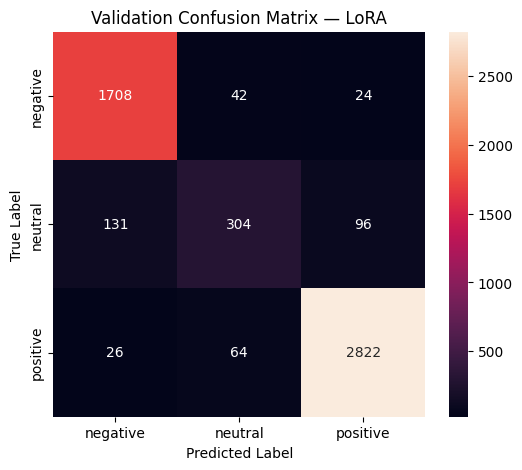

In [81]:
val_cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    val_cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Validation Confusion Matrix — LoRA")
plt.show()


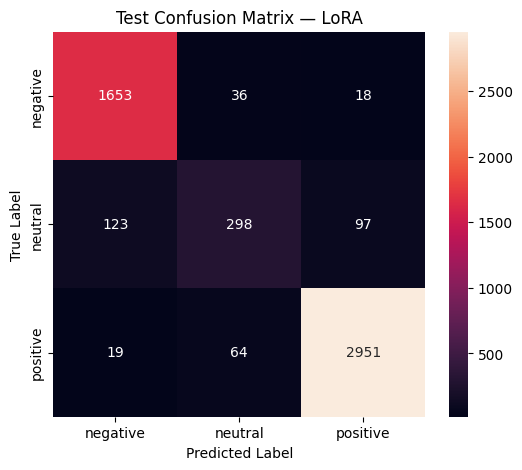

In [82]:
test_cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Test Confusion Matrix — LoRA")
plt.show()


In [83]:
save_path = "./deberta_absa_opinion_lora_best"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("LoRA adapter saved to:", save_path)


LoRA adapter saved to: ./deberta_absa_opinion_lora_best


In [84]:
trainable_params = 0
all_params = 0

for _, param in model.named_parameters():
    all_params += param.numel()
    if param.requires_grad:
        trainable_params += param.numel()

print(f"Trainable params: {trainable_params:,}")
print(f"All params:       {all_params:,}")
print(f"Trainable %:      {100 * trainable_params / all_params:.4f}%")


Trainable params: 3,247,107
All params:       187,671,558
Trainable %:      1.7302%


# Comparison Between the Baseline Model and the LoRA Fine-Tuned Model

### 1. Overall Results

The following table compares the pretrained **DeBERTa-v3-base baseline** with the **LoRA fine-tuned DeBERTa-v3-base** model on the same validation and test splits.

| Model | Split | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---|---:|---:|---:|---:|
| Baseline DeBERTa-v3-base | Validation | 0.4150 | 0.2892 | 0.3226 | 0.2913 |
| LoRA Fine-Tuned DeBERTa-v3-base | Validation | 0.8447 | 0.7614 | 0.7140 | 0.7308 |
| Baseline DeBERTa-v3-base | Test | 0.4330 | 0.3032 | 0.3376 | 0.3029 |
| LoRA Fine-Tuned DeBERTa-v3-base | Test | 0.8481 | 0.7504 | 0.7085 | 0.7240 |

### 2. Improvement After LoRA Fine-Tuning

#### Validation Improvement
- **Accuracy:** +0.4297
- **Macro Precision:** +0.4722
- **Macro Recall:** +0.3914
- **Macro F1:** +0.4395

#### Test Improvement
- **Accuracy:** +0.4151
- **Macro Precision:** +0.4472
- **Macro Recall:** +0.3709
- **Macro F1:** +0.4211

These results show that LoRA fine-tuning produced a very large improvement over the baseline across all evaluation metrics. The most important gain is in **Macro F1**, which increased from **0.3029** to **0.7240** on the test set. Since Macro F1 gives equal importance to all sentiment classes, it is a more reliable indicator than accuracy alone for evaluating performance on an imbalanced dataset.

---

### 3. Class-Wise Test Comparison

#### Baseline Test Classification Report
| Class | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Negative | 0.33 | 0.60 | 0.43 |
| Neutral | 0.00 | 0.00 | 0.00 |
| Positive | 0.58 | 0.41 | 0.48 |

#### LoRA Fine-Tuned Test Classification Report
| Class | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Negative | 0.87 | 0.84 | 0.86 |
| Neutral | 0.51 | 0.35 | 0.41 |
| Positive | 0.87 | 0.94 | 0.90 |

### 4. Class-Wise Interpretation

The baseline model showed weak multiclass behavior. Its most serious weakness was the **neutral** class, where it achieved **0.00 precision, 0.00 recall, and 0.00 F1-score** on the test set. This means that the baseline did **not predict the neutral class at all**. Therefore, although the baseline reached moderate accuracy, it did not function as a proper three-class sentiment classifier.

In contrast, the LoRA fine-tuned model learned a much healthier class distribution. It achieved strong performance on both the **negative** and **positive** classes, with F1-scores of approximately **0.86** and **0.90**, respectively. More importantly, it was also able to recognize the **neutral** class, reaching an F1-score of **0.41**. Although neutral remained the most difficult class, it was no longer completely ignored, which represents a major improvement over the baseline.

---

### 5. Confusion Matrix Analysis

The confusion matrices further highlight the difference between the two models.

#### Baseline Model
- The baseline produced **no neutral predictions**.
- Neutral examples were misclassified as either negative or positive.
- There was also strong confusion between negative and positive samples.
- This indicates that the baseline behaved more like a weak binary classifier than a true three-class sentiment classifier.

#### LoRA Fine-Tuned Model
- The confusion matrix became much more diagonal, which indicates better classification quality.
- Most **negative** and **positive** examples were classified correctly.
- The model also started to identify **neutral** examples, although some confusion still remained between neutral and the neighboring sentiment classes.
- Overall, the LoRA fine-tuned model showed much better separation between the three sentiment categories.

---

### 6. Important Training Note

It is important to note that the LoRA experiment was trained for only **3 epochs**, even though the original plan allowed for more training. This limitation was due to **time constraints**, not because the model had necessarily reached its full potential.

Therefore, the current LoRA results should be considered **strong but not necessarily final-best performance**. Since the model was trained under a limited epoch budget, it is reasonable to say that, with more training time and proper early stopping, the performance could potentially improve further. However, this should not be stated as guaranteed; it is more accurate to say that the model likely still had room for additional optimization.

---

### 7. Parameter Efficiency Compared to Full Fine-Tuning

One of the main advantages of LoRA is that it updates only a small fraction of the model parameters instead of fine-tuning the entire model.

| Method | Trainable Parameters | Total Parameters | Trainable Percentage |
|---|---:|---:|---:|
| Full Fine-Tuning | 187,671,558 | 187,671,558 | 100.00% |
| LoRA Fine-Tuning | 3,247,107 | 187,671,558 | 1.73% |

Compared to full fine-tuning, LoRA reduced the number of trainable parameters by:

- **184,424,451 parameters**
- which is approximately **98.27% fewer trainable parameters**

This means that LoRA achieved performance that was much stronger than the baseline while training only a very small portion of the full model parameters.

---

### 8. Final Conclusion

The comparison clearly shows that **LoRA fine-tuning dramatically outperformed the baseline model**. The pretrained baseline was not sufficient for this ABSA sentiment classification task, mainly because it failed to model the three sentiment classes properly and completely missed the neutral class. After LoRA fine-tuning, the model achieved strong and much more balanced performance, with large improvements in accuracy, macro precision, macro recall, and macro F1.

In addition, these results were obtained after only **3 training epochs** due to time limitations. This means that the achieved performance is already very strong, while further training could potentially lead to even better results. Most importantly, LoRA achieved this improvement while training only **1.73%** of the model parameters, reducing the trainable parameter count by about **98.27%** compared to full fine-tuning. Overall, the experiment confirms that **parameter-efficient fine-tuning is highly effective** for this problem and that the final input design based on **Aspect + Opinion + Review** helped the model learn sentiment distinctions much more effectively than the baseline model.